# Patent Factor Analysis - Incremental

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from typing import List, Optional, Union, Tuple, Dict
from scipy.stats import spearmanr
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1. Load & Prepare Data

In [2]:
market_cap = pd.read_csv('data/market_cap.csv', index_col=0)
adjclose = pd.read_csv('data/adjclose.csv', index_col=0)

trade_days = market_cap.index
adjclose = adjclose.loc[trade_days]
monthly_returns = adjclose.shift(-1) / adjclose - 1

In [3]:
indus_df_raw = pd.read_excel('data/行业分类表中信.xlsx')

indus_df = indus_df_raw.set_index("证券代码")
indus_df.columns = ['证券简称', '一级行业', 'code1', '二级行业', 'code2']

ticker_industry_mapping = indus_df['一级行业'].to_dict()

ticker_industry_mapping_rev = {}
for key, v in ticker_industry_mapping.items():
    if str(v) == 'nan':
        continue
    try:
        ticker_industry_mapping_rev[v].append(key)
    except:
        ticker_industry_mapping_rev[v] = [key]

indus_count = {name: len(ticker_industry_mapping_rev[name]) for name in ticker_industry_mapping_rev}
print("行业数量：", len(indus_count))
print("行业覆盖股票数量：", sum(indus_count.values()))  
print("行业覆盖股票数量占比：", sum(indus_count.values()) / len(indus_df))

indus_count

行业数量： 30
行业覆盖股票数量： 5522
行业覆盖股票数量占比： 0.9848403780988051


{'建筑': 171,
 '房地产': 127,
 '消费者服务': 62,
 '综合': 43,
 '医药': 506,
 '石油石化': 59,
 '家电': 89,
 '建材': 93,
 '钢铁': 59,
 '汽车': 250,
 '非银行金融': 76,
 '基础化工': 511,
 '电力设备及新能源': 321,
 '商贸零售': 119,
 '交通运输': 131,
 '电力及公用事业': 237,
 '计算机': 362,
 '综合金融': 17,
 '传媒': 159,
 '国防军工': 122,
 '有色金属': 136,
 '机械': 665,
 '煤炭': 37,
 '农林牧渔': 110,
 '通信': 133,
 '纺织服装': 106,
 '电子': 478,
 '轻工制造': 169,
 '食品饮料': 132,
 '银行': 42}

In [4]:
patent_raw = pd.read_excel('data/PT_LCDOMFORAPPLY.xlsx')
patent = patent_raw.drop([0, 1]).reset_index(drop=True)

def get_ticker(code: str) -> str:
    """
    根据 A 股证券代码生成完整 Ticker（带交易所后缀），如 '000001.SZ'
    """
    if code.startswith(("6", "9")):    # 上交所：以 6、9 开头（主板、科创板等）
        return f"{code}.SH"
    elif code.startswith(("0", "3")):  # 深交所：0 是主板、3 是创业板
        return f"{code}.SZ"
    elif code.startswith(("2")):       # B 股（200）
        return f"{code}.SZ"
    elif code.startswith(("430")):     # 北交所：430 是北交所
        return f"{code}.BJ"
    elif code.startswith(("8")):       # 新三板：8 是新三板 后转北交所
        return f"{code}.BJ"
    else:
        raise ValueError(f"未知的证券代码开头: {code}")

patent['Symbol'] = patent['Symbol'].map(get_ticker)

# for incremental, cumsum using ffill after filtering S5206
patent[['Invention', 'UtilityModel', 'Design']] = patent[['Invention', 'UtilityModel', 'Design']].fillna(0)
patent['Patents'] = patent['Patents'].fillna(patent['Invention'] + patent['UtilityModel'] + patent['Design'])

patent = patent.loc[patent['Area'] == 1]          # 国内的专利
patent = patent.loc[patent['StateTypeCode'] == 1] # 合并报表

In [5]:
# 1 for authorized / acquired, 2 for applied
patent_1 = patent[patent['ApplyTypeCode'].isin(['S5202', 'S5203', 'S5204', 'S5206'])].copy()
patent_2 = patent[patent['ApplyTypeCode'].isin(['S5201', 'S5205'])].copy()

patent_1['Type'] = np.where(
    patent_1['ApplyTypeCode'].isin(['S5204', 'S5206']),'cumulative',
    np.where(patent_1['ApplyTypeCode'].isin(['S5202', 'S5203']), 'incremental', np.nan)
)
patent_1.drop(columns=['Area', 'StateTypeCode', 'ApplyTypeCode', 'ApplyType'], inplace=True)

patent_2['Type'] = np.where(
    patent_2['ApplyTypeCode'].isin(['S5205']),'cumulative',
    np.where(patent_2['ApplyTypeCode'].isin(['S5201']), 'incremental', np.nan)
)
patent_2.drop(columns=['Area', 'StateTypeCode', 'ApplyTypeCode', 'ApplyType'], inplace=True)

In [6]:
def process_patent_data(patent, patent_type: str):
    """
    Group by stocks and calculate on a yearly basis. 
    Priority: Original cumulative calculated increment > Original increment. 
    """
    # Create a copy to avoid modifying the original dataframe
    patent_processed = patent.copy()
    patent_processed['remove'] = False  # Add column to mark records for removal
    
    # Group by Symbol
    grouped = patent_processed.groupby('Symbol')
    
    for symbol, group in grouped:

        # Determine initial cumulative baseline
        initial_cum = 0
        first_cum_found = False
        
        # Find the earliest reliable cumulative value by working backwards
        for idx in range(len(group)):
            record = group.iloc[idx]
            if record['Type'] == 'cumulative' and not first_cum_found:
                # Calculate what the initial_cum should be by working backwards
                temp_cum = record[patent_type]
                
                # Look at all incremental records before this cumulative record
                for prev_idx in range(idx):
                    prev_record = group.iloc[prev_idx]
                    if prev_record['Type'] == 'incremental':
                        temp_cum -= prev_record[patent_type]
                
                initial_cum = max(temp_cum, 0)  # Ensure non-negative
                first_cum_found = True
                break

        # Reset variables for each stock group
        cum = initial_cum
        count = 1
        date_exist = []
        
        # Get indices for this group
        group_indices = group.index.tolist()
        
        for idx, (_, record) in enumerate(group.iterrows()):
            current_idx = group_indices[idx]
            
            if count == 1:  # First record
                if record['Type'] == 'cumulative':
                    cum = record[patent_type]
                    patent_processed.loc[current_idx, 'Type'] = 'incremental'
                else:
                    cum += record[patent_type]
                count = 0
            else:  # Not first record
                if record['EndDate'] not in date_exist:
                    if record['Type'] == 'cumulative':
                        inc = max(record[patent_type] - cum, 0)
                        cum = record[patent_type]
                        patent_processed.loc[current_idx, patent_type] = inc
                        patent_processed.loc[current_idx, 'Type'] = 'incremental'
                    else:
                        cum += record[patent_type]
                else:  # Date already exists
                    if record['Type'] == 'cumulative':
                        if record[patent_type] != cum:
                            # Get previous record index
                            prev_idx = group_indices[idx - 1]
                            prev_patents = patent_processed.loc[prev_idx, patent_type]
                            inc = max(record[patent_type] - (cum - prev_patents), 0)
                            patent_processed.loc[prev_idx, patent_type] = inc
                            cum = record[patent_type]
                    else:
                        # Get previous record index
                        prev_idx = group_indices[idx - 1]
                        if patent_processed.loc[prev_idx, patent_type] == 0:
                            patent_processed.loc[prev_idx, patent_type] = record[patent_type]
                    
                    # Mark this record for removal
                    patent_processed.loc[current_idx, 'remove'] = True
            
            # Add current date to date_exist
            date_exist.append(record['EndDate'])
    
    patent_processed = patent_processed[patent_processed['remove'] == False].drop(columns=['remove', 'Type']).reset_index(drop=True)
    
    return patent_processed

In [7]:
def convert_yearly_to_monthly(df: pd.DataFrame, trade_days: pd.Index) -> pd.DataFrame:    
    df.index = [int(i.replace("-", "")) for i in df.index]
    
    union = list(trade_days)
    union.extend(list(df.index))
    union = list(set(union))
    union.sort()

    df_converted = df.reindex(union).ffill().loc[trade_days]
    return df_converted

In [8]:
def get_type_count(patent_1, patent_2, trade_days):
    result_1 = {}
    result_2 = {}
    for i in ['Patents', 'Invention', 'UtilityModel', 'Design']:
        result_1[i] = convert_yearly_to_monthly(process_patent_data(patent_1[['Symbol', 'EndDate', i, 'Type']].copy(), i).pivot(index='EndDate', columns='Symbol', values=i).fillna(0), trade_days)
        result_2[i] = convert_yearly_to_monthly(process_patent_data(patent_2[['Symbol', 'EndDate', i, 'Type']].copy(), i).pivot(index='EndDate', columns='Symbol', values=i).fillna(0), trade_days)

    return result_1, result_2

result_1, result_2 = get_type_count(patent_1, patent_2, trade_days)

In [9]:
# Industry selection

# 转换为 DataFrame
df = pd.Series(ticker_industry_mapping, name="industry").to_frame()

# 创建 dummy 变量
dummy_df = pd.get_dummies(df['industry'])

select_industries = [
    '基础化工',
    '机械' ,
    '电子' ,
    '汽车' ,
    '有色金属' ,
    '通信' ,
    '医药' ,
    '建材' ,
    '钢铁',
    '轻工制造',
    '计算机' ,
    '电力设备及新能源' ,
    '家电' ,
    '建筑' ,
    '国防军工',
    '石油石化'
]

dummy_df = dummy_df[select_industries]
dummy_df = dummy_df.map(lambda x: 1 if x else 0)
dummy_df = dummy_df.loc[dummy_df.sum(1) > 0]

print(dummy_df.sum())

基础化工        511
机械          665
电子          478
汽车          250
有色金属        136
通信          133
医药          506
建材           93
钢铁           59
轻工制造        169
计算机         362
电力设备及新能源    321
家电           89
建筑          171
国防军工        122
石油石化         59
dtype: int64


In [10]:
def calc_ic(factor: pd.DataFrame, monthly_ret: pd.DataFrame, cal_factor_return = False, use_spearman=True) -> Tuple[Dict, pd.Series] :
    ic = {}
    fr = {}
    ts = factor.index.intersection(monthly_ret.index)
    ts = ts[:-1]  # 排除最后一天的因子

    for day in ts:
        f_i = factor.loc[day].dropna()
        r_i = monthly_ret.loc[day].dropna()
        common_assets = f_i.index.intersection(r_i.index)

        if len(common_assets) == 0:
            # print("factor value all nan in", day)
            # ic[day] = np.nan
            fr[day] = np.nan
            continue

        if f_i.std() == 0:
            # print("same factor value in", day)
            ic[day] = np.nan
            fr[day] = np.nan
            continue

        f_i = f_i.loc[common_assets]
        r_i = r_i.loc[common_assets]

        # 计算 IC（信息系数，即因子值和未来收益的 Spearman 相关系数）
        if use_spearman:
            ic[day], _ = spearmanr(f_i, r_i)
        else:
            ic[day] = np.corrcoef(f_i, r_i)[0, 1]

        # 横截面回归，r_i = alpha + beta * f_i + epsilon，beta 就是因子收益
        # 做这个回归需要对因子进行归一化, 只有这样得出的回归系数才有真实的意义
        # 因为这个操作比较耗时，初筛时可以选择不做，得出的结论和 IC 差不多
        if cal_factor_return:
            f_i = (f_i - f_i.mean()) / f_i.std()
            X = sm.add_constant(f_i)  # 添加截距项
            model = sm.OLS(r_i, X)
            results = model.fit()
            fr[day] = results.params[f_i.name] if f_i.name in results.params else results.params[1]
        else:
            fr[day] = 0

    ic_series = pd.Series(ic)
    fr_series = pd.Series(fr)
    n = fr_series.count()
    mean = fr_series.mean()
    std = fr_series.std(ddof=1)

    summary = {
        "IC": ic_series.mean(),
        "IC_positive": sum(ic_series > 0) / len(ic_series),
        "IR": ic_series.mean() / ic_series.std() if ic_series.std() != 0 else np.nan,
        "Factor Mean Return": fr_series.mean(),
        "Factor Return tstat":  mean / (std / np.sqrt(n)) if std > 0 else np.nan
    }

    return summary, fr_series

In [11]:
def convert_index_to_datetime(df: Union[pd.DataFrame, pd.Series]):
    index = df.index
    # 判断是否是形如 20250101 的整数或字符串格式
    if all(isinstance(i, (int, str)) and len(str(i)) == 8 for i in index):
        try:
            df.index = pd.to_datetime(index, format="%Y%m%d")
        except Exception as e:
            print("转换失败：", e)
    else:
        print("索引不是 yyyymmdd 格式，未做转换")
    return df

In [12]:
def rowwise_residuals(df1: pd.DataFrame, df2: pd.DataFrame, industry_dummy: pd.DataFrame) -> pd.DataFrame:
    """
    industry_dummy: shape = (n_assets, n_industries)
    df1, df2: shape = (n_samples, n_assets)
    
    对 df1 的每一行 y，用 df2 的对应行 + 行业哑变量作为 X 做 OLS，输出残差
    """
    assert df1.shape == df2.shape, "df1 和 df2 的 shape 必须一致"
    assert df1.shape[1] == industry_dummy.shape[0], "df1 的列数（资产数）必须与 industry_dummy 的行数一致"

    residuals = []
    index = df1.index
    columns = df1.columns

    # 预处理行业哑变量（资产数 × 行业数）
    industry_matrix = industry_dummy.values  # shape = (n_assets, n_industries)

    for i in range(len(df1)):
        y = df1.iloc[i].values           # shape = (n_assets,)
        x_factor = df2.iloc[i].values    # shape = (n_assets,)

        # 处理缺失和异常
        if pd.isna(y).all() or pd.isna(x_factor).all() or np.std(x_factor) == 0:
            residuals.append([np.nan] * len(y))
            continue

        # 去均值 + 缺失填充
        y_centered = y - np.nanmean(y)
        y_clean = np.nan_to_num(y_centered, nan=0.0)

        x_centered = x_factor - np.nanmean(x_factor)
        x_clean = np.nan_to_num(x_centered, nan=0.0)

        # 拼接：列拼接为 design matrix: [x_clean | industry_dummies]
        X_full = np.column_stack([x_clean, industry_matrix])  # shape: (n_assets, 1 + n_industries)

        # 加入截距项
        X_full = sm.add_constant(X_full)

        # 回归
        model = sm.OLS(y_clean, X_full)
        results = model.fit()

        eps = results.resid
        residuals.append(eps)

    res_df = pd.DataFrame(residuals, index=index, columns=columns)
    return res_df

In [13]:
def gen_factors(market_cap, result_1, result_2, dummy_df, universe: Optional[pd.DataFrame]=None):
    factors = {}
    new_universe = dummy_df.index
    
    log_market_cap = np.log(market_cap.reindex(columns=new_universe))

    result_1 = {k: v.reindex(columns=new_universe).fillna(0) for k, v in result_1.items()}
    result_2 = {k: v.reindex(columns=new_universe).fillna(0) for k, v in result_2.items()}

    # Authorized / Acquired Patents
    total_1 = result_1['Patents']
    invention_1 = result_1['Invention']
    utility_1 = result_1['UtilityModel']
    design_1 = result_1['Design']
    # Applied Patents
    total_2 = result_2['Patents']
    invention_2 = result_2['Invention']
    utility_2 = result_2['UtilityModel']
    design_2 = result_2['Design']

    # 1Y
    factors['patents_accepted_1Y'] = rowwise_residuals(total_1, log_market_cap, dummy_df)
    factors['invention_accepted_1Y'] = rowwise_residuals(invention_1, log_market_cap, dummy_df)
    factors['utility_accepted_1Y'] = rowwise_residuals(utility_1, log_market_cap, dummy_df)
    factors['design_accepted_1Y'] = rowwise_residuals(design_1, log_market_cap, dummy_df)

    factors['patents_applied_1Y'] = rowwise_residuals(total_2, log_market_cap, dummy_df)
    factors['invention_applied_1Y'] = rowwise_residuals(invention_2, log_market_cap, dummy_df)
    factors['utility_applied_1Y'] = rowwise_residuals(utility_2, log_market_cap, dummy_df)
    factors['design_applied_1Y'] = rowwise_residuals(design_2, log_market_cap, dummy_df)
    
    # 2Y
    factors['patents_accepted_2Y'] = rowwise_residuals(total_1.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['invention_accepted_2Y'] = rowwise_residuals(invention_1.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['utility_accepted_2Y'] = rowwise_residuals(utility_1.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['design_accepted_2Y'] = rowwise_residuals(design_1.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)

    factors['patents_applied_2Y'] = rowwise_residuals(total_2.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['invention_applied_2Y'] = rowwise_residuals(invention_2.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['utility_applied_2Y'] = rowwise_residuals(utility_2.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['design_applied_2Y'] = rowwise_residuals(design_2.rolling(window=2*12, min_periods=1).sum(), log_market_cap, dummy_df)

    # 3Y
    factors['patents_accepted_3Y'] = rowwise_residuals(total_1.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['invention_accepted_3Y'] = rowwise_residuals(invention_1.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['utility_accepted_3Y'] = rowwise_residuals(utility_1.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['design_accepted_3Y'] = rowwise_residuals(design_1.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)

    factors['patents_applied_3Y'] = rowwise_residuals(total_2.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['invention_applied_3Y'] = rowwise_residuals(invention_2.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['utility_applied_3Y'] = rowwise_residuals(utility_2.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)
    factors['design_applied_3Y'] = rowwise_residuals(design_2.rolling(window=3*12, min_periods=1).sum(), log_market_cap, dummy_df)

    if not universe is None:
        for f, v in factors.items():
            v = v.loc[universe.index]
            factors[f] = v * universe
    return factors

In [14]:
my_factors = gen_factors(market_cap, result_1, result_2, dummy_df)

res_all = {}
factor_ret_all = {}
for factor_name, factor_value in my_factors.items():
    try:
        summary, fr_series = calc_ic(factor_value, monthly_returns, cal_factor_return=True, use_spearman=True)
        res_all[factor_name] = summary
        factor_ret_all[factor_name] = fr_series
    except:
        raise Exception(f"[{factor_name}] Error")
    
res_all = pd.DataFrame(res_all).T
res_all

,IC,IC_positive,IR,Factor Mean Return,Factor Return tstat
patents_accepted_1Y,0.043557,0.676647,0.394771,1.695196e-03,6.112497
invention_accepted_1Y,0.036102,0.664671,0.340711,1.054844e-03,4.761582
utility_accepted_1Y,0.009223,0.497006,0.114072,7.205451e-05,0.301208
design_accepted_1Y,-0.011497,0.455090,-0.127446,2.580497e-04,1.122696
patents_applied_1Y,0.047114,0.682635,0.415396,1.614029e-03,6.085198
invention_applied_1Y,0.042138,0.652695,0.364293,1.270791e-03,5.826173
utility_applied_1Y,0.015182,0.514970,0.163504,-8.660413e-05,-0.491473
design_applied_1Y,0.002420,0.473054,0.023957,-6.770501e-07,-0.003290
patents_accepted_2Y,0.048672,0.694611,0.459015,1.981826e-03,5.983714
invention_accepted_2Y,0.041597,0.688623,0.415213,1.194726e-03,5.173953


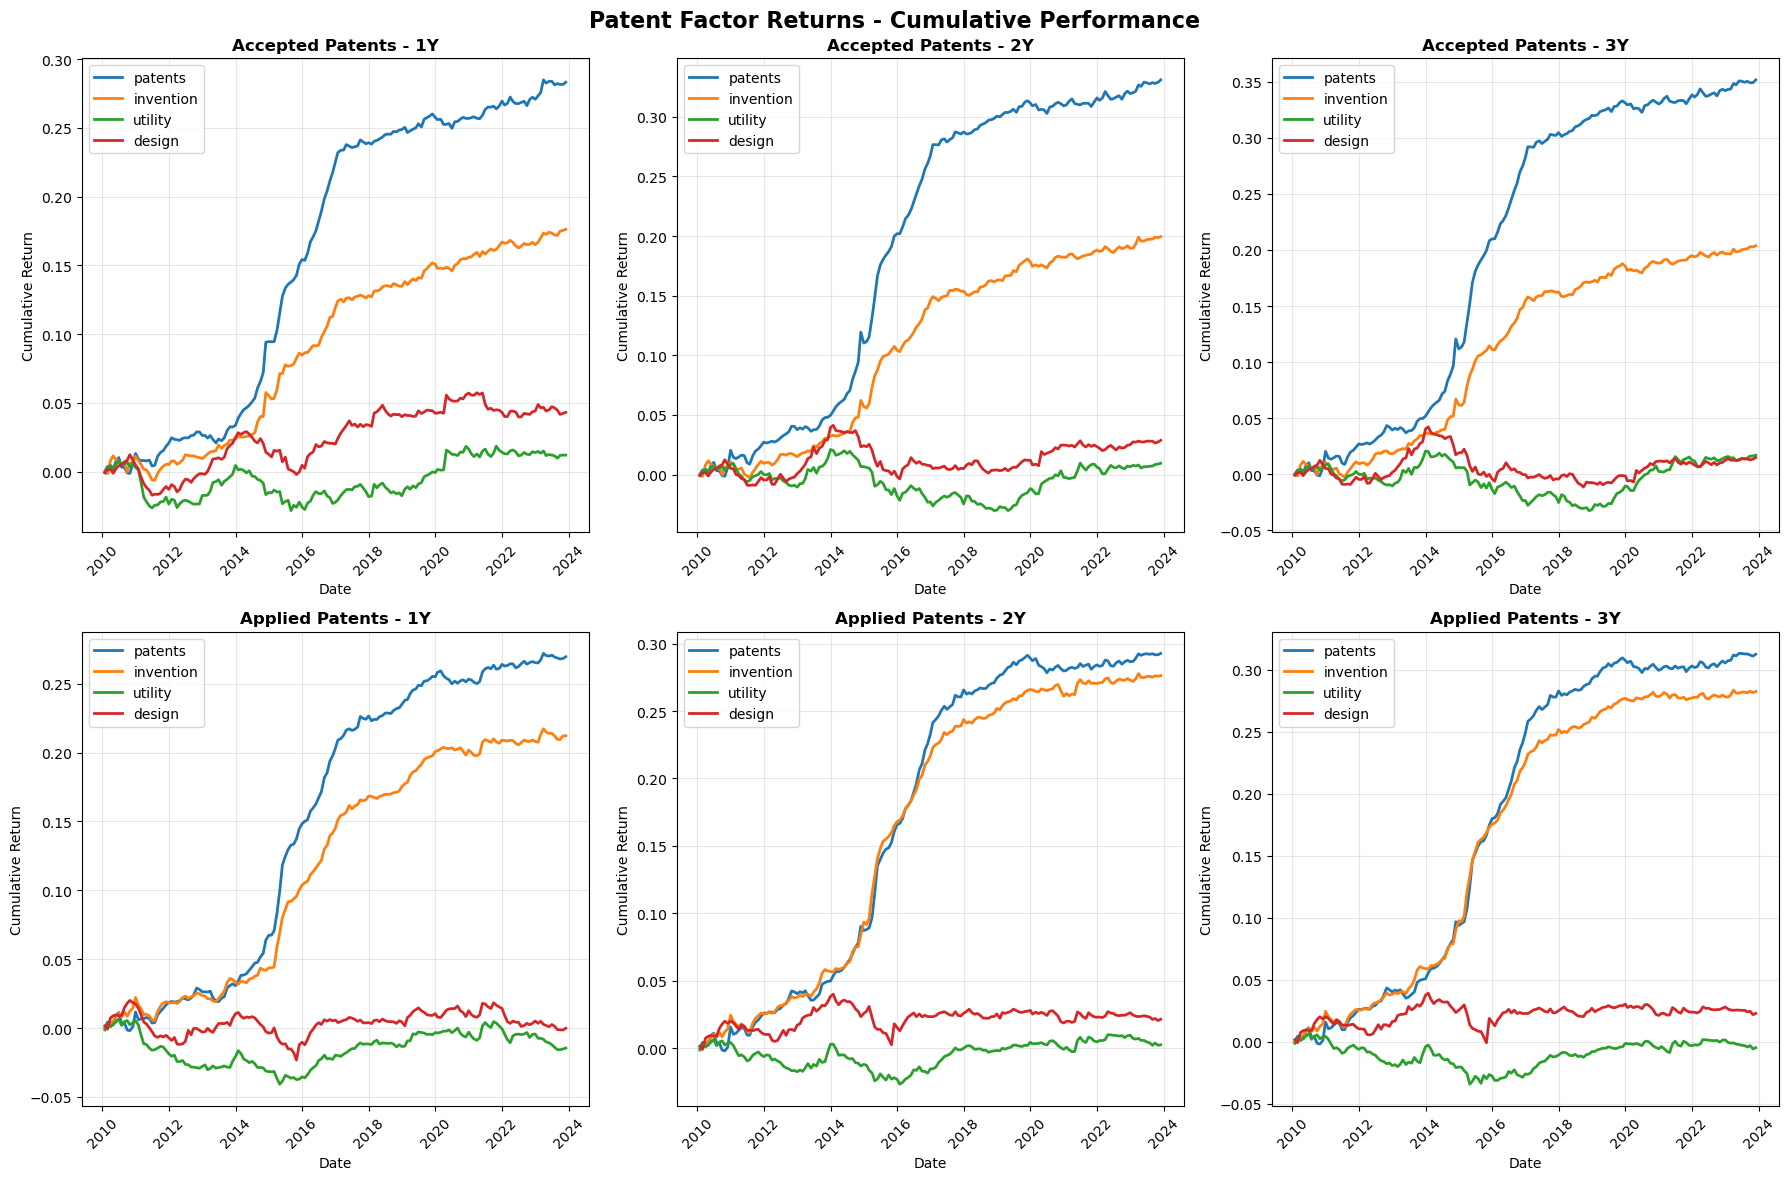

In [15]:
# Plot returns

# Prepare the data
factor_ret_all = pd.DataFrame(factor_ret_all)
factor_ret_all = convert_index_to_datetime(factor_ret_all)
factor_ret_cumsum = factor_ret_all.cumsum()

# Define the structure for plotting
years = ['1Y', '2Y', '3Y']
types = ['accepted', 'applied']
patent_categories = ['patents', 'invention', 'utility', 'design']

# Create 6 subplots (3 years × 2 types)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Patent Factor Returns - Cumulative Performance', fontsize=16, fontweight='bold')

for i, patent_type in enumerate(types):
    for j, year in enumerate(years):
        ax = axes[i, j]
        
        # Plot each patent category for the current type and year
        for category in patent_categories:
            factor_name = f'{category}_{patent_type}_{year}'
            if factor_name in factor_ret_cumsum.columns:
                ax.plot(factor_ret_cumsum.index, factor_ret_cumsum[factor_name], 
                       label=category, linewidth=2)
        
        # Customize the subplot
        ax.set_title(f'{patent_type.capitalize()} Patents - {year}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
        ax.set_xlabel('Date')
        ax.set_ylabel('Cumulative Return')
        
        # Rotate x-axis labels for better readability
        ax.tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Single-Factor Enhancement Strategy

In [16]:
import cvxpy as cp
from scipy.optimize import minimize

def single_factor_portfolio_optimization(factor_scores, returns, benchmark_weights=None, 
                                       l=1.5, b=0.8, i_upper=1.8, i_lower=1.2, 
                                       x_upper=0.95, x_lower=1.05, d_bench=1, 
                                       transaction_cost=0.003):
    """
    单因子增强模型优化策略
    
    Args:
        factor_scores: Series, 因子得分向量 μ
        returns: Series, 预期收益率 (可选，如果没有可用因子得分代替)
        benchmark_weights: Series, 基准权重 w_bench
        l: float, 个股权重上限 (1.5%)
        b: float, 成分股权重占比下限 (0.8)
        i_upper: float, 行业暴露度上限 (1.8)
        i_lower: float, 行业暴露度下限 (1.2)
        x_upper: float, 风格因子暴露度上限 (0.95)
        x_lower: float, 风格因子暴露度下限 (1.05)
        d_bench: float, 成分股暴露度 (1)
        transaction_cost: float, 手续费 (0.3%)
    
    Returns:
        dict: 包含优化权重和相关信息的字典
    """
    
    common_assets = factor_scores.index
    n_assets = len(common_assets)
    
    # 如果没有提供基准权重，使用等权重
    if benchmark_weights is None:
        benchmark_weights = pd.Series(1/n_assets, index=common_assets)
    else:
        benchmark_weights = benchmark_weights.reindex(common_assets).fillna(0)
    
    # create optimization variables
    w = cp.Variable(n_assets)  # composite weights
    
    # optimization: Max F(w) = w^T μ
    mu = factor_scores.reindex(common_assets).fillna(0).values
    objective = cp.Maximize(w.T @ mu)
    
    constraints = []
    
    constraints.append(cp.sum(w) == 1)
    constraints.append(w >= 0)
    constraints.append(w <= l/100)  # l% = 1.5%
    
    # suppose all stocks are constituent stocks
    constraints.append(cp.sum(w) >= b) 
    
    # exposure constraint: D_bench * w >= b
    # assume D_bench = 1
    constraints.append(cp.sum(w) >= b)
    
    problem = cp.Problem(objective, constraints)
    
    # Use OSQP solver
    # ??? ECOS 因为某些原因失效了 ???
    try:
        problem.solve(solver=cp.OSQP)
        
        if problem.status not in ["infeasible", "unbounded"]:
            optimal_weights = pd.Series(w.value, index=common_assets)
            
            results = {
                'optimal_weights': optimal_weights,
                'objective_value': problem.value,
                'factor_exposure': optimal_weights @ factor_scores.reindex(common_assets).fillna(0),
                'benchmark_weights': benchmark_weights,
                'active_weights': optimal_weights - benchmark_weights,
                'tracking_error': np.sqrt(((optimal_weights - benchmark_weights) ** 2).sum()),
                'status': problem.status
            }
            
            return results
        else:
            # If OSQP fails, try SCS
            problem.solve(solver=cp.SCS)
            if problem.status not in ["infeasible", "unbounded"]:
                optimal_weights = pd.Series(w.value, index=common_assets)
                
                results = {
                    'optimal_weights': optimal_weights,
                    'objective_value': problem.value,
                    'factor_exposure': optimal_weights @ factor_scores.reindex(common_assets).fillna(0),
                    'benchmark_weights': benchmark_weights,
                    'active_weights': optimal_weights - benchmark_weights,
                    'tracking_error': np.sqrt(((optimal_weights - benchmark_weights) ** 2).sum()),
                    'status': problem.status
                }
                
                return results
            else:
                print(f"Both OSQP and SCS optimization failed: {problem.status}")
                return None
            
    except Exception as e:
        print(f"Optimization error: {e}")
        return None

def backtest_factor_strategy(factor_data, returns_data, rebalance_freq='M'):
    portfolio_returns = []
    portfolio_weights_history = []
    rebalance_dates = []
    
    # get rebalance dates
    if rebalance_freq == 'M':
        rebalance_dates = factor_data.index[:-1]  # excluding last date
    
    for i, date in enumerate(rebalance_dates):
        try:
            current_factors = factor_data.loc[date].dropna()
            
            if len(current_factors) < 10:
                continue
                
            opt_result = single_factor_portfolio_optimization(
                factor_scores=current_factors,
                returns=None, 
                l=1.5, b=0.8
            )
            
            if opt_result is None:
                continue
                
            optimal_weights = opt_result['optimal_weights']
            portfolio_weights_history.append(optimal_weights)
            
            if i < len(rebalance_dates) - 1:
                next_date = rebalance_dates[i + 1]
                next_returns = returns_data.loc[next_date]
                
                common_assets = optimal_weights.index.intersection(next_returns.index)
                if len(common_assets) > 0:
                    portfolio_return = (optimal_weights.loc[common_assets] * 
                                      next_returns.loc[common_assets]).sum()
                    portfolio_returns.append(portfolio_return)
                    
        except Exception as e:
            print(f"Failed to process date {date}: {e}")
            continue
    
    portfolio_returns = pd.Series(portfolio_returns, index=rebalance_dates[1:len(portfolio_returns)+1])
    
    results = {
        'portfolio_returns': portfolio_returns,
        'cumulative_returns': (1 + portfolio_returns).cumprod(),
        'weights_history': portfolio_weights_history,
        'annual_return': portfolio_returns.mean() * 12,
        'annual_volatility': portfolio_returns.std() * np.sqrt(12),
        'sharpe_ratio': (portfolio_returns.mean() * 12) / (portfolio_returns.std() * np.sqrt(12)),
        'max_drawdown': (1 + portfolio_returns).cumprod().expanding().max() - (1 + portfolio_returns).cumprod()
    }
    
    return results

Selected factor: patents_applied_2Y

=== Single Factor Strategy Backtest Results ===
Annual Return: 13.24%
Annual Volatility: 24.57%
Sharpe Ratio: 0.539
Max Drawdown: 157.22%


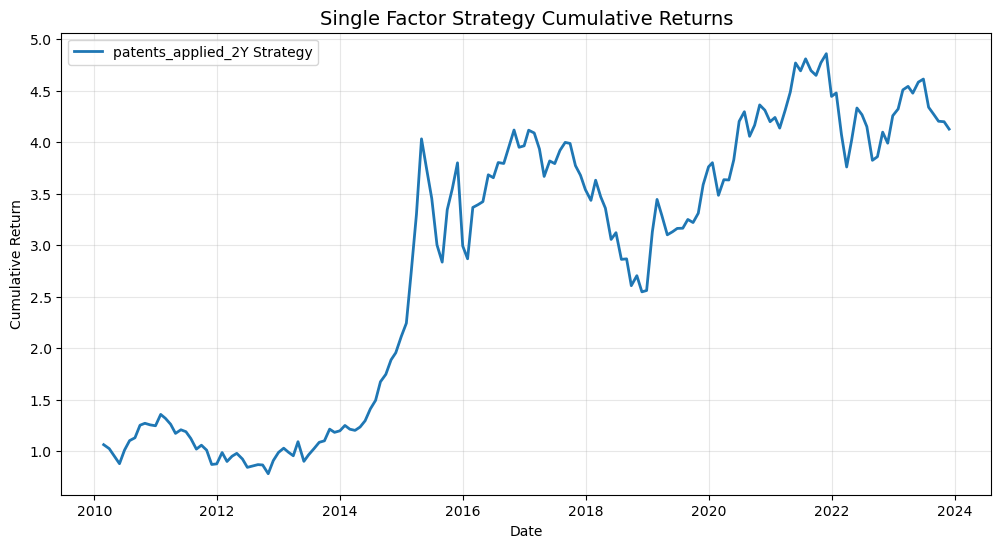

In [17]:
# use factor with highest IC
best_factor_name = res_all.sort_values('IC', ascending=False).index[0]
print(f"Selected factor: {best_factor_name}")

factor_data = my_factors[best_factor_name]

strategy_results = backtest_factor_strategy(factor_data, monthly_returns)

if strategy_results['portfolio_returns'] is not None and len(strategy_results['portfolio_returns']) > 0:
    print("\n=== Single Factor Strategy Backtest Results ===")
    print(f"Annual Return: {strategy_results['annual_return']:.2%}")
    print(f"Annual Volatility: {strategy_results['annual_volatility']:.2%}")
    print(f"Sharpe Ratio: {strategy_results['sharpe_ratio']:.3f}")
    print(f"Max Drawdown: {strategy_results['max_drawdown'].max():.2%}")
    
    # plot cum-retuurn
    plt.figure(figsize=(12, 6))
    strategy_cumret = convert_index_to_datetime(strategy_results['cumulative_returns'])
    plt.plot(strategy_cumret.index, strategy_cumret.values, label=f'{best_factor_name} Strategy', linewidth=2)
    plt.title('Single Factor Strategy Cumulative Returns', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Strategy backtest failed, please check data")

In [18]:
def generate_comprehensive_factor_report(factor_name, factor_data, monthly_returns, strategy_results):
    # Chinese font settings
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Factor Performance Chart
    ax1 = plt.subplot(2, 1, 1)
    
    factor_returns = strategy_results['portfolio_returns']
    factor_cumret = strategy_results['cumulative_returns']
    
    benchmark_returns = monthly_returns.mean(axis=1)
    benchmark_cumret = (1 + benchmark_returns).cumprod()
    
    # Find common index between factor and benchmark
    common_index = factor_returns.index.intersection(benchmark_returns.index)
    
    if len(common_index) == 0:
        print("No common dates found, using forward fill method")
        # Use forward fill to align benchmark with factor dates
        benchmark_cumret_aligned = benchmark_cumret.reindex(factor_returns.index, method='ffill')
    else:
        print(f"Found {len(common_index)} common dates")
        # Use only common dates
        factor_cumret = factor_cumret.reindex(common_index)
        benchmark_cumret_aligned = benchmark_cumret.reindex(common_index)
    
    # Convert to datetime
    factor_cumret_dt = convert_index_to_datetime(factor_cumret)
    benchmark_cumret_dt = convert_index_to_datetime(benchmark_cumret_aligned)
    
    # Plot both lines
    ax1.plot(factor_cumret_dt.index, factor_cumret_dt.values, 
             label=f'{factor_name} Strategy', linewidth=2.5, color='purple')
    ax1.plot(benchmark_cumret_dt.index, benchmark_cumret_dt.values, 
             label='Benchmark (Equal Weight)', linewidth=2, color='orange')
    
    ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    
    ax1.set_title(f'Factor Performance: {factor_name}', fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Cumulative Return', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    ax1.tick_params(axis='x', rotation=45)
    
    # Rest of your code remains the same...
    # 2. Annual Performance Table
    ax2 = plt.subplot(2, 1, 2)
    ax2.axis('tight')
    ax2.axis('off')
    
    annual_stats = calculate_annual_performance(factor_returns, benchmark_returns)
    
    table_data = []
    headers = ['Year', 'Win Rate', 'Annual Return', 'Annual Volatility', 'Sharpe Ratio', 
               'Max Drawdown', 'Benchmark Return', 'Excess Return', 'Information Ratio']
    
    for year, stats in annual_stats.items():
        row = [
            str(year),
            f"{stats['win_rate']:.1%}",
            f"{stats['annual_return']:.2%}",
            f"{stats['annual_volatility']:.2%}",
            f"{stats['sharpe_ratio']:.2f}",
            f"{stats['max_drawdown']:.2%}",
            f"{stats['benchmark_return']:.2%}",
            f"{stats['excess_return']:.2%}",
            f"{stats['information_ratio']:.2f}"
        ]
        table_data.append(row)
    
    # Add summary row
    summary_stats = calculate_summary_stats(factor_returns, benchmark_returns)
    summary_row = [
        'Summary',
        f"{summary_stats['win_rate']:.1%}",
        f"{summary_stats['annual_return']:.2%}",
        f"{summary_stats['annual_volatility']:.2%}",
        f"{summary_stats['sharpe_ratio']:.2f}",
        f"{summary_stats['max_drawdown']:.2%}",
        f"{summary_stats['benchmark_return']:.2%}",
        f"{summary_stats['excess_return']:.2%}",
        f"{summary_stats['information_ratio']:.2f}"
    ]
    table_data.append(summary_row)
    
    # Create table
    table = ax2.table(cellText=table_data, colLabels=headers, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    for i in range(len(headers)):
        table[(0, i)].set_facecolor('#4472C4')
        table[(0, i)].set_text_props(weight='bold', color='white')

    for i in range(len(headers)):
        table[(len(table_data), i)].set_facecolor('#E7E6E6')
        table[(len(table_data), i)].set_text_props(weight='bold')

    ax2.set_title(f'Annual Performance Breakdown: {factor_name}', 
                  fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    return fig

Found 166 common dates


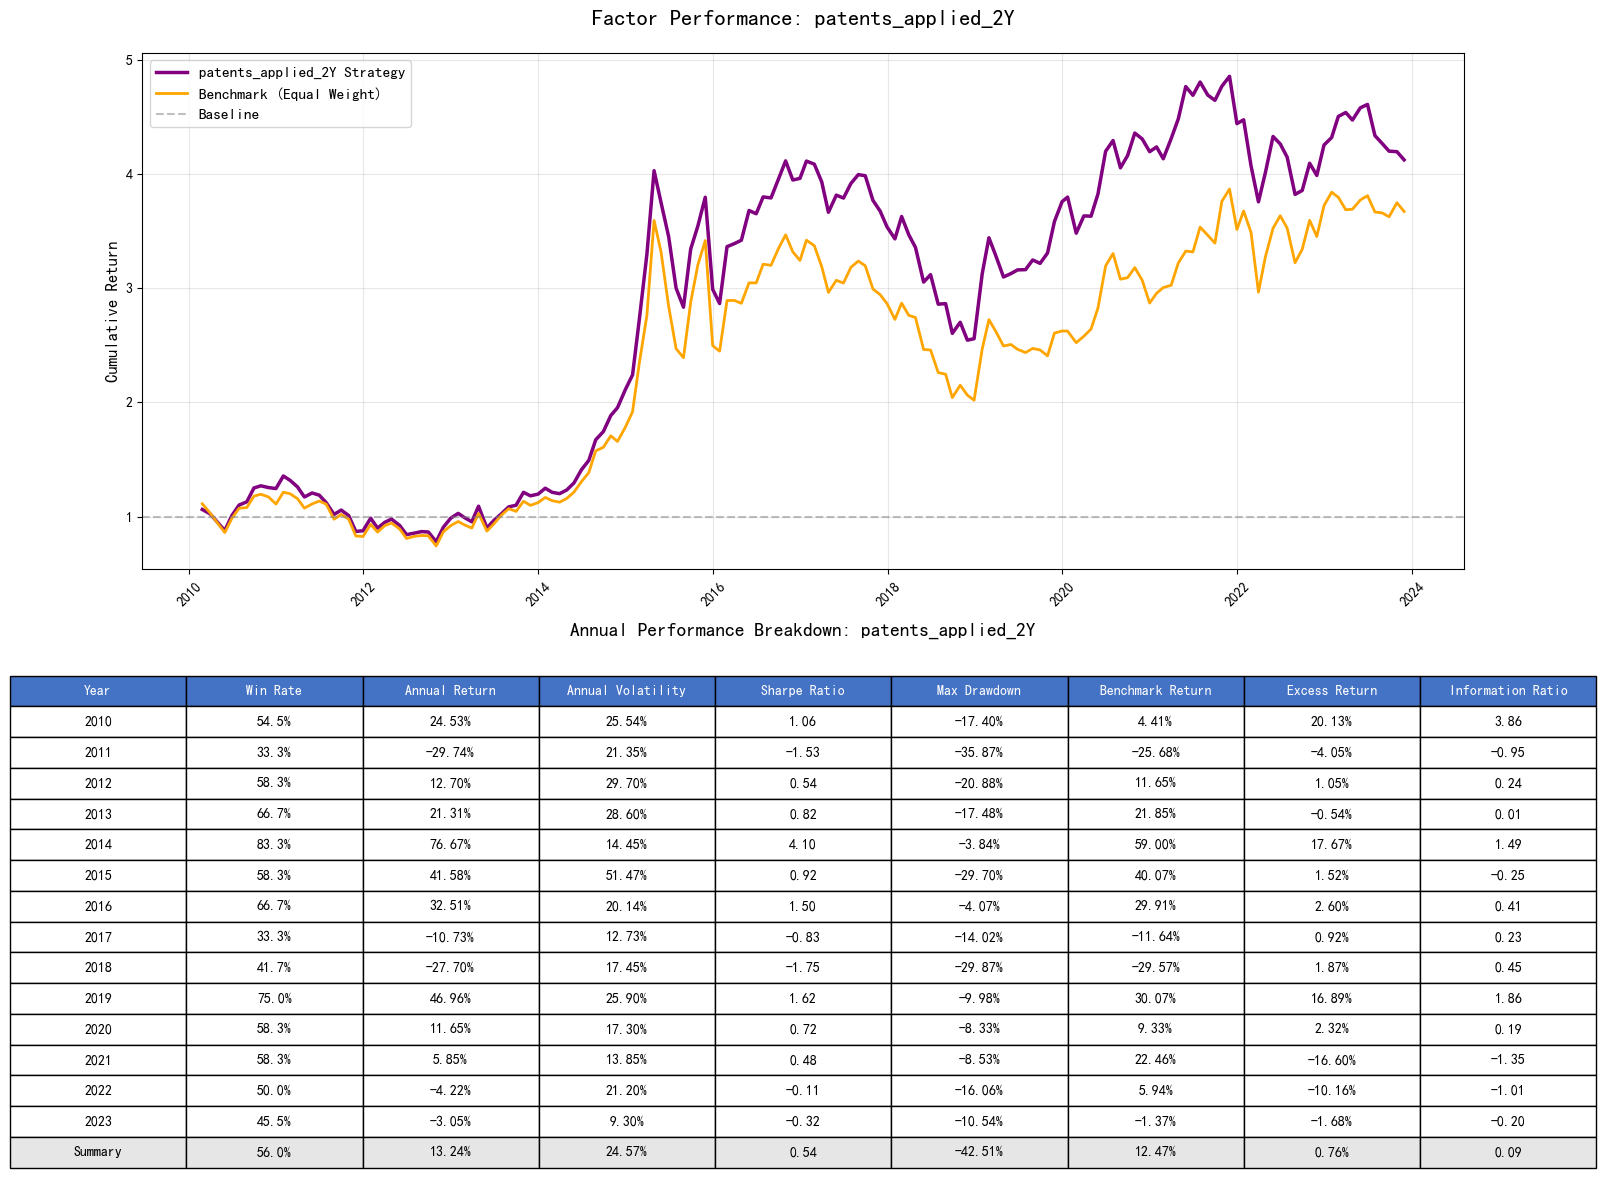

=== COMPREHENSIVE FACTOR REPORT ===
Factor: patents_applied_2Y
Analysis Period: 20100226 to 20231130
Total Return: 312.77%
Annualized Return: 13.24%
Annualized Volatility: 24.57%
Sharpe Ratio: 0.539
Max Drawdown: 157.22%


In [19]:
def calculate_annual_performance(factor_returns, benchmark_returns):
    # Convert to datetime index
    factor_returns_dt = convert_index_to_datetime(factor_returns.copy())
    benchmark_returns_dt = convert_index_to_datetime(benchmark_returns.reindex(factor_returns.index).copy())
    
    annual_stats = {}
    
    for year in factor_returns_dt.index.year.unique():
        year_factor = factor_returns_dt[factor_returns_dt.index.year == year]
        year_benchmark = benchmark_returns_dt[benchmark_returns_dt.index.year == year]
        
        if len(year_factor) == 0:
            continue
            
        annual_return = (1 + year_factor).prod() - 1
        annual_volatility = year_factor.std() * np.sqrt(12)
        sharpe_ratio = year_factor.mean() / year_factor.std() * np.sqrt(12) if year_factor.std() > 0 else 0
        
        # Max drawdown
        cumret = (1 + year_factor).cumprod()
        running_max = cumret.expanding().max()
        drawdown = (cumret - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # Benchmark performance
        benchmark_annual_return = (1 + year_benchmark).prod() - 1
        excess_return = annual_return - benchmark_annual_return
        
        # Win rate (percentage of positive returns)
        win_rate = (year_factor > 0).mean()
        
        # Information ratio
        excess_returns = year_factor - year_benchmark
        information_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(12) if excess_returns.std() > 0 else 0
        
        annual_stats[year] = {
            'win_rate': win_rate,
            'annual_return': annual_return,
            'annual_volatility': annual_volatility,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'benchmark_return': benchmark_annual_return,
            'excess_return': excess_return,
            'information_ratio': information_ratio
        }
    
    return annual_stats

def calculate_summary_stats(factor_returns, benchmark_returns):
    
    factor_returns_dt = convert_index_to_datetime(factor_returns.copy()) # already in datetime format
    benchmark_returns_dt = convert_index_to_datetime(benchmark_returns.reindex(factor_returns.index).copy())
    
    # Overall statistics
    annual_return = factor_returns_dt.mean() * 12
    annual_volatility = factor_returns_dt.std() * np.sqrt(12)
    sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0
    
    # Max drawdown
    cumret = (1 + factor_returns_dt).cumprod()
    running_max = cumret.expanding().max()
    drawdown = (cumret - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Benchmark performance
    benchmark_annual_return = benchmark_returns_dt.mean() * 12
    excess_return = annual_return - benchmark_annual_return
    
    # Win rate
    win_rate = (factor_returns_dt > 0).mean()
    
    # Information ratio
    excess_returns = factor_returns_dt - benchmark_returns_dt
    information_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(12) if excess_returns.std() > 0 else 0
    
    return {
        'win_rate': win_rate,
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'benchmark_return': benchmark_annual_return,
        'excess_return': excess_return,
        'information_ratio': information_ratio
    }

# Generate comprehensive report
best_factor_name = res_all.sort_values('IC', ascending=False).index[0]
factor_data = my_factors[best_factor_name]
strategy_results = backtest_factor_strategy(factor_data, monthly_returns)

# Generate the report
if strategy_results['portfolio_returns'] is not None and len(strategy_results['portfolio_returns']) > 0:
    fig = generate_comprehensive_factor_report(best_factor_name, factor_data, monthly_returns, strategy_results)
    plt.show()
    
    # Also print key statistics
    print("=== COMPREHENSIVE FACTOR REPORT ===")
    print(f"Factor: {best_factor_name}")
    print(f"Analysis Period: {strategy_results['portfolio_returns'].index[0]} to {strategy_results['portfolio_returns'].index[-1]}")
    print(f"Total Return: {(strategy_results['cumulative_returns'].iloc[-1] - 1):.2%}")
    print(f"Annualized Return: {strategy_results['annual_return']:.2%}")
    print(f"Annualized Volatility: {strategy_results['annual_volatility']:.2%}")
    print(f"Sharpe Ratio: {strategy_results['sharpe_ratio']:.3f}")
    print(f"Max Drawdown: {strategy_results['max_drawdown'].max():.2%}")
else:
    print("Strategy backtest failed, please check data")

<span style="color:red">要添加alpha的线</span>